# iMLE performance

Reconstructing the `cat` state from measurements of the Husimi Q function using
iterative Maximum Likelihood Estimation (iMLE).

The cat state is defined as:

$$|\psi_{\text{cat}} \rangle = \frac{1}{\mathcal N} ( |\alpha \rangle + |-\alpha \rangle \big ) $$

with $\alpha=2$ and normalization $\mathcal N$.

## Husimi Q function measurements

The Husimi Q function can be obtained by calculating the expectation value of measuring the following operator:

$$\mathcal O_i = \frac{1}{\pi}|\beta_i \rangle \langle \beta_i|$$

where $|\beta_i \rangle $ are coherent states written in the Fock basis.


In [3]:
import numpy as np

from qutip import coherent, coherent_dm, expect, Qobj, fidelity, rand_dm
from qutip.wigner import wigner, qfunc

import tensorflow as tf

from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/Users/owendugan/mambaforge/envs/quantum/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


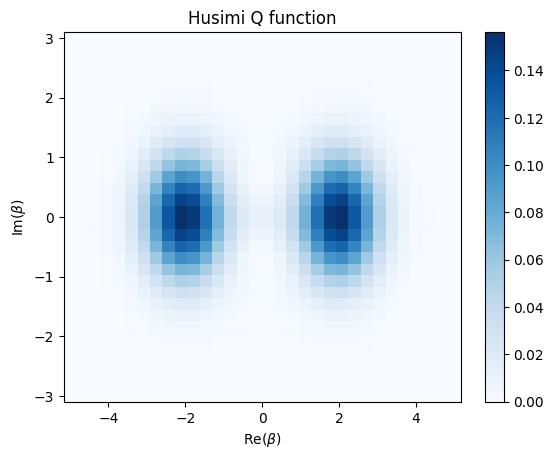

In [4]:
hilbert_size = 32
alpha = 2

psi = coherent(hilbert_size, alpha) + coherent(hilbert_size, -alpha)
psi = psi.unit() # The .unit() function normalizes the state to have unit trace

grid = 32
xvec = np.linspace(-5, 5, grid)
yvec = np.linspace(-3, 3, grid)

q = qfunc(psi, xvec, yvec, g=2)

cmap = "Blues"
im = plt.pcolor(xvec, yvec, q, vmin=0, vmax=np.max(q), cmap=cmap, shading='auto')
plt.colorbar(im)
plt.xlabel(r"Re($\beta$)")
plt.ylabel(r"Im($\beta$)")
plt.title("Husimi Q function")
plt.show()

# Construct the measurement operators and simulated data (without any noise)

In [5]:
X, Y = np.meshgrid(xvec, yvec)
betas = (X + 1j*Y).ravel()
m_ops = [coherent_dm(hilbert_size, beta) for beta in betas]
ops_numpy = [op.full() for op in m_ops]

data = expect(m_ops, psi)
rho_true = psi*psi.dag()

# Iterative maximum likelihood estimation

In [6]:
import math

In [7]:
def rho_to_Q(rho, xvec, yvec):
    alphas = xvec + 1j*yvec

    alphas = np.expand_dims(alphas, -1)
    
    As = []
    for i in range(rho.shape[-1]):
        As.append(
            (alphas ** i)/math.sqrt(math.factorial(i))
        )

    As = np.concatenate(As, axis=-1)

    As *= np.exp(-np.abs(alphas)**2/2)

    return np.fmax(np.real(np.einsum("ijk,...kl,ijl->...ij",np.conj(As),rho,As)/math.pi),1e-30)


def L1_loss(Q_true, Q_pred, xvec, yvec):
    return np.sum(np.abs(Q_true - Q_pred)) * (xvec[0,1] - xvec[0,0]) * (yvec[1,0] - yvec[0,0])

def KL_rev_loss(Q_true, Q_pred, xvec, yvec):
    return np.sum(Q_true * np.log(Q_true/Q_pred)) * (xvec[0,1] - xvec[0,0]) * (yvec[1,0] - yvec[0,0])

def KL_loss(Q_true, Q_pred, xvec, yvec):
    return np.sum(Q_pred * np.log(Q_pred/Q_true)) * (xvec[0,1] - xvec[0,0]) * (yvec[1,0] - yvec[0,0])

def add_losses(losses, rho_true, rho_pred, xvec, yvec, i):
    Q_true = rho_to_Q(rho_true, xvec, yvec)
    Q_pred = rho_to_Q(rho_pred, xvec, yvec)

    #plt.imshow(Q_true - Q_pred)
    #plt.show()

    losses["L1"].append(L1_loss(Q_true, Q_pred, xvec, yvec))
    losses["KL"].append(KL_loss(Q_true, Q_pred, xvec, yvec))
    losses["KL_rev"].append(KL_rev_loss(Q_true, Q_pred, xvec, yvec))
    losses["p_L2"].append(np.sum(np.abs(np.array(rho_true) - np.array(rho_pred)) ** 2))

In [8]:
X, Y = np.meshgrid(np.arange(-20,20,0.4), np.arange(-20,20,0.4))

In [9]:
losses = {"L1": [], "KL": [], "KL_rev": [], "F": [], "p_L2": []}
max_iterations = 500

rho = rand_dm(hilbert_size, 0.8)

add_losses(losses, rho_true, rho, X, Y, 0)
losses["F"].append(fidelity(rho_true, rho))


for i in range(max_iterations):
    guessed_val = expect(m_ops, rho)
    ratio = data / guessed_val

    R = Qobj(np.einsum("aij,a->ij", ops_numpy, ratio))
    rho = R * rho * R
    rho = rho / rho.tr()

    add_losses(losses, rho_true, rho, X, Y, i)
    losses["F"].append(fidelity(rho_true, rho))

    if i % 100 == 0:
        print(f"Epoch {i}: L1 {losses['L1'][-1]:.4f} KL {losses['KL'][-1]:.4f} KL_rev {losses['KL_rev'][-1]:.4f}")

Epoch 0: L1 0.2237 KL 0.0619 KL_rev 0.0432
Epoch 100: L1 0.0249 KL 0.0014 KL_rev 0.0007
Epoch 200: L1 0.0112 KL 0.0008 KL_rev 0.0003
Epoch 300: L1 0.0075 KL 0.0006 KL_rev 0.0002
Epoch 400: L1 0.0061 KL 0.0004 KL_rev 0.0002


In [10]:
import pickle
pickle.dump(losses, open("loss_evolution/imle_losses.dat", "wb"))

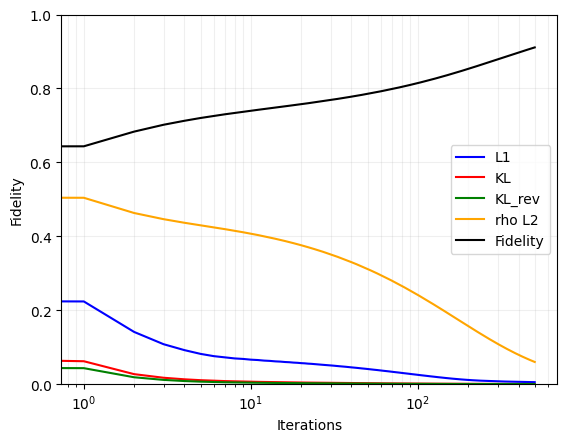

In [11]:
iterations = np.arange(len(losses["L1"]))
plt.plot(iterations, losses["L1"], color="blue", label="L1")
plt.plot(iterations, losses["KL"], color="red", label="KL")
plt.plot(iterations, losses["KL_rev"], color="green", label="KL_rev")
plt.plot(iterations, losses["p_L2"], color="orange", label="rho L2")
plt.plot(iterations, losses["F"], color="black", label="Fidelity")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Fidelity")
plt.ylim(0,1)
plt.grid(which='minor', alpha=0.2)
plt.grid(which='major', alpha=0.2)
plt.xscale('log')
#plt.yscale('log')
plt.show()

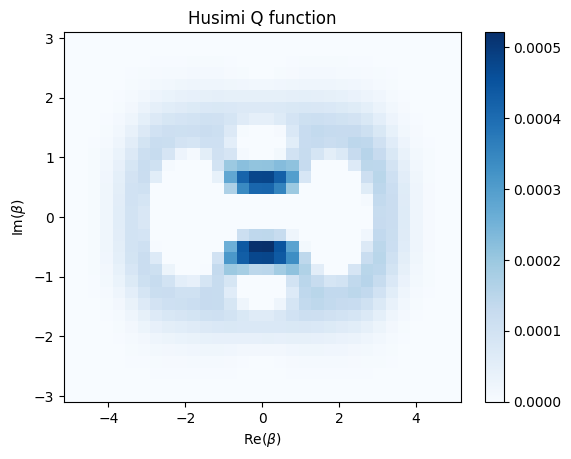

In [12]:
q = qfunc(rho, xvec, yvec, g=2)
q_true = qfunc(rho_true, xvec, yvec, g=2)

cmap = "Blues"
im = plt.pcolor(xvec, yvec, q-q_true, vmin=0, vmax=np.max(q-q_true), cmap=cmap, shading='auto')
plt.colorbar(im)
plt.xlabel(r"Re($\beta$)")
plt.ylabel(r"Im($\beta$)")
plt.title("Husimi Q function")
plt.show()